# Data Processing Framework Benchmark: Feature Selection Optimization
This notebook evaluates and compares the performance of **Pandas, Dask, and PySpark**.
The optimization technique tested is **Feature Selection** (dropping columns early vs. late).

**Requirements:**
Make sure you have the following installed in your environment:
`pip install pandas dask pyspark psutil matplotlib seaborn`

In [1]:
pip install pandas dask[dataframe] pyspark psutil matplotlib seaborn --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import dask.dataframe as dd
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, upper
import numpy as np
import time
import psutil
import os
import threading
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# ---------------------------------------------------------
# Resource Monitor (Captures CPU and Memory in background)
# ---------------------------------------------------------
class ResourceMonitor:
    def __init__(self):
        self.keep_measuring = True
        self.cpu_measurements = []
        self.mem_measurements = []
        self.process = psutil.Process(os.getpid())

    def measure(self):
        # Initialize CPU percent baseline
        self.process.cpu_percent(interval=None)
        while self.keep_measuring:
            try:
                # Measure CPU and Memory of the main process and any child processes (like JVM for PySpark or Dask workers)
                cpu = self.process.cpu_percent(interval=None)
                mem = self.process.memory_info().rss
                
                for child in self.process.children(recursive=True):
                    try:
                        cpu += child.cpu_percent(interval=None)
                        mem += child.memory_info().rss
                    except (psutil.NoSuchProcess, psutil.AccessDenied):
                        pass
                        
                self.cpu_measurements.append(cpu)
                # Convert bytes to Megabytes (MB)
                self.mem_measurements.append(mem / (1024 * 1024))
            except Exception:
                pass
            time.sleep(0.1)

    def start(self):
        self.keep_measuring = True
        self.thread = threading.Thread(target=self.measure)
        self.thread.start()

    def stop(self):
        self.keep_measuring = False
        self.thread.join()
        
        avg_cpu = sum(self.cpu_measurements) / len(self.cpu_measurements) if self.cpu_measurements else 0.0
        peak_mem = max(self.mem_measurements) if self.mem_measurements else 0.0
        return avg_cpu, peak_mem

---
## Configuration & Dataset Setup
Here we generate a dummy dataset and provide the **placeholder block** where you can manually define which features to keep for the optimization pipeline.

In [3]:
DATA_FILE = 'cleaned_data.csv'

# =====================================================================
# 🛠️ PLACEHOLDER: SPECIFY FEATURES TO KEEP OR DROP HERE
# =====================================================================
# This list determines which columns are retained during Feature Selection.
features_to_keep = [
    'id', 'title', 'author', 'tags', 'description'
]
# =====================================================================

---
## Defining the Pipelines
For each framework (Pandas, Dask, PySpark), we define two versions:
1. **Baseline (Unoptimized):** Loads all data, applies transformations to *all* columns, and then drops the unwanted features at the end.
2. **Optimized (Feature Selection Early):** Selects only the necessary columns right at the beginning, reducing the data volume before transformations.

In [4]:
# Initialize PySpark Session
spark = SparkSession.builder \
    .appName("FeatureSelectionBenchmark") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

# --- 1. PANDAS PIPELINES ---
def pandas_baseline():
    # Load all data explicitly as strings
    df = pd.read_csv(DATA_FILE, dtype=str)
    
    # Baseline: Apply string uppercase transformation to ALL columns first
    for col_name in df.columns:
        df[col_name] = df[col_name].str.upper()
        
    # Late feature selection (dropping columns at the very end)
    df = df[features_to_keep]
    return len(df)

def pandas_optimized():
    # Early feature selection: only load the columns we actually want to keep
    df = pd.read_csv(DATA_FILE, usecols=features_to_keep, dtype=str)
    
    # Optimized: Apply string transformation ONLY to the selected columns
    for col_name in df.columns:
        df[col_name] = df[col_name].str.upper()
        
    return len(df)

# --- 2. DASK PIPELINES ---
def dask_baseline():
    # Load all columns as string data
    ddf = dd.read_csv(DATA_FILE, dtype=str)
    
    # Baseline: Uppercase conversion across ALL string columns
    for col_name in ddf.columns:
        ddf[col_name] = ddf[col_name].str.upper()
        
    ddf = ddf[features_to_keep]
    return len(ddf.compute())

def dask_optimized():
    # Early feature selection during initial CSV load
    ddf = dd.read_csv(DATA_FILE, usecols=features_to_keep, dtype=str)
    
    # Optimized: Uppercase conversion ONLY on selected features
    for col_name in ddf.columns:
        ddf[col_name] = ddf[col_name].str.upper()
        
    return len(ddf.compute())

# --- 3. PYSPARK PIPELINES ---
def pyspark_baseline():
    # Load data without inferring schemas (defaults to string type)
    df = spark.read.csv(DATA_FILE, header=True, inferSchema=False) 
    
    # Baseline: Perform heavy uppercase loop across every column in the dataset
    for col_name in df.columns:
        df = df.withColumn(col_name, upper(df[col_name]))
            
    # Late feature selection
    df = df.select(*features_to_keep)
    return df.count()

def pyspark_optimized():
    df = spark.read.csv(DATA_FILE, header=True, inferSchema=False)
    
    # Early feature selection: narrow down column volume immediately
    df = df.select(*features_to_keep)
    
    # Optimized: Only modify the columns we care about
    for col_name in df.columns:
        df = df.withColumn(col_name, upper(df[col_name]))
            
    return df.count()

---
## Benchmarking Execution
This section runs the functions exactly 3 times for every framework and version.
It calculates the averages and saves the detailed metrics into `performance_before.csv` and `performance_after.csv`.

In [5]:
def run_experiments(pipeline_func, framework, version, runs=3):
    print(f"Running {framework} - {version}...")
    results = []
    
    for i in range(1, runs + 1):
        monitor = ResourceMonitor()
        monitor.start()
        
        start_time = time.time()
        records = pipeline_func()
        end_time = time.time()
        
        avg_cpu, peak_mem = monitor.stop()
        total_time = end_time - start_time
        throughput = records / total_time if total_time > 0 else 0
        
        results.append({
            'Framework': framework,
            'Version': version,
            'Run': i,
            'Total_Time_sec': round(total_time, 4),
            'Avg_CPU_percent': round(avg_cpu, 2),
            'Peak_Memory_MB': round(peak_mem, 2),
            'Throughput_rec_per_sec': round(throughput, 2)
        })
        print(f"  Run {i} | Time: {total_time:.2f}s | CPU: {avg_cpu:.1f}% | Mem: {peak_mem:.0f}MB | T/P: {throughput:.0f} r/s")
        
    # Calculate averages
    avg_time = sum(r['Total_Time_sec'] for r in results) / runs
    avg_cpu = sum(r['Avg_CPU_percent'] for r in results) / runs
    avg_mem = sum(r['Peak_Memory_MB'] for r in results) / runs
    avg_tp = sum(r['Throughput_rec_per_sec'] for r in results) / runs
    
    # Append the average row
    results.append({
        'Framework': framework,
        'Version': version,
        'Run': 'Average',
        'Total_Time_sec': round(avg_time, 4),
        'Avg_CPU_percent': round(avg_cpu, 2),
        'Peak_Memory_MB': round(peak_mem, 2),
        'Throughput_rec_per_sec': round(avg_tp, 2)
    })
    
    return results

# Dictionaries to hold our functions
baseline_funcs = {
    'Pandas': pandas_baseline,
    'Dask': dask_baseline,
    'PySpark': pyspark_baseline
}

optimized_funcs = {
    'Pandas': pandas_optimized,
    'Dask': dask_optimized,
    'PySpark': pyspark_optimized
}

# 1. Run Baseline (Before Optimization)
print("=== STARTING BASELINE BENCHMARKS ===")
results_before = []
for fw, func in baseline_funcs.items():
    results_before.extend(run_experiments(func, fw, 'Baseline'))

# 2. Run Optimized (After Optimization)
print("\n=== STARTING OPTIMIZED BENCHMARKS ===")
results_after = []
for fw, func in optimized_funcs.items():
    results_after.extend(run_experiments(func, fw, 'Optimized'))

# Save to CSV
df_before = pd.DataFrame(results_before)
df_after = pd.DataFrame(results_after)

df_before.to_csv("performance_before.csv", index=False)
df_after.to_csv("performance_after.csv", index=False)

print("\nSuccess! Results saved to 'performance_before.csv' and 'performance_after.csv'.")

=== STARTING BASELINE BENCHMARKS ===
Running Pandas - Baseline...
  Run 1 | Time: 2.19s | CPU: 94.6% | Mem: 974MB | T/P: 86333 r/s
  Run 2 | Time: 2.25s | CPU: 94.1% | Mem: 1214MB | T/P: 84129 r/s
  Run 3 | Time: 2.24s | CPU: 93.0% | Mem: 1379MB | T/P: 84583 r/s
Running Dask - Baseline...
  Run 1 | Time: 2.75s | CPU: 107.3% | Mem: 1201MB | T/P: 68883 r/s
  Run 2 | Time: 2.04s | CPU: 115.5% | Mem: 1134MB | T/P: 92769 r/s
  Run 3 | Time: 1.98s | CPU: 115.8% | Mem: 1137MB | T/P: 95568 r/s
Running PySpark - Baseline...
  Run 1 | Time: 3.72s | CPU: 8.6% | Mem: 939MB | T/P: 50954 r/s
  Run 2 | Time: 0.65s | CPU: 9.4% | Mem: 1016MB | T/P: 293180 r/s
  Run 3 | Time: 0.47s | CPU: 11.3% | Mem: 1076MB | T/P: 403160 r/s

=== STARTING OPTIMIZED BENCHMARKS ===
Running Pandas - Optimized...
  Run 1 | Time: 1.58s | CPU: 93.0% | Mem: 1109MB | T/P: 119948 r/s
  Run 2 | Time: 1.53s | CPU: 91.8% | Mem: 1188MB | T/P: 124142 r/s
  Run 3 | Time: 1.52s | CPU: 91.4% | Mem: 1332MB | T/P: 124298 r/s
Running Dask

---
## Visualization & Evaluation Output
Here we extract the `Average` rows from our results and generate clear tables and color-coded bar charts comparing the frameworks.
* **Pandas**: Blue
* **Dask**: Orange
* **PySpark**: Green


=== AVERAGE PERFORMANCE (BEFORE OPTIMIZATION) ===


,Framework,Total_Time_sec,Avg_CPU_percent,Peak_Memory_MB,Throughput_rec_per_sec
3,Pandas,2.2281,93.91,1379.19,85015.13
7,Dask,2.2576,112.87,1137.43,85740.10
11,PySpark,1.6110,9.76,1076.33,249098.09



=== AVERAGE PERFORMANCE (AFTER OPTIMIZATION) ===


,Framework,Total_Time_sec,Avg_CPU_percent,Peak_Memory_MB,Throughput_rec_per_sec
3,Pandas,1.5428,92.06,1332.43,122796.16
7,Dask,1.4505,116.79,1415.54,130787.18
11,PySpark,0.3497,7.45,1221.14,541946.42


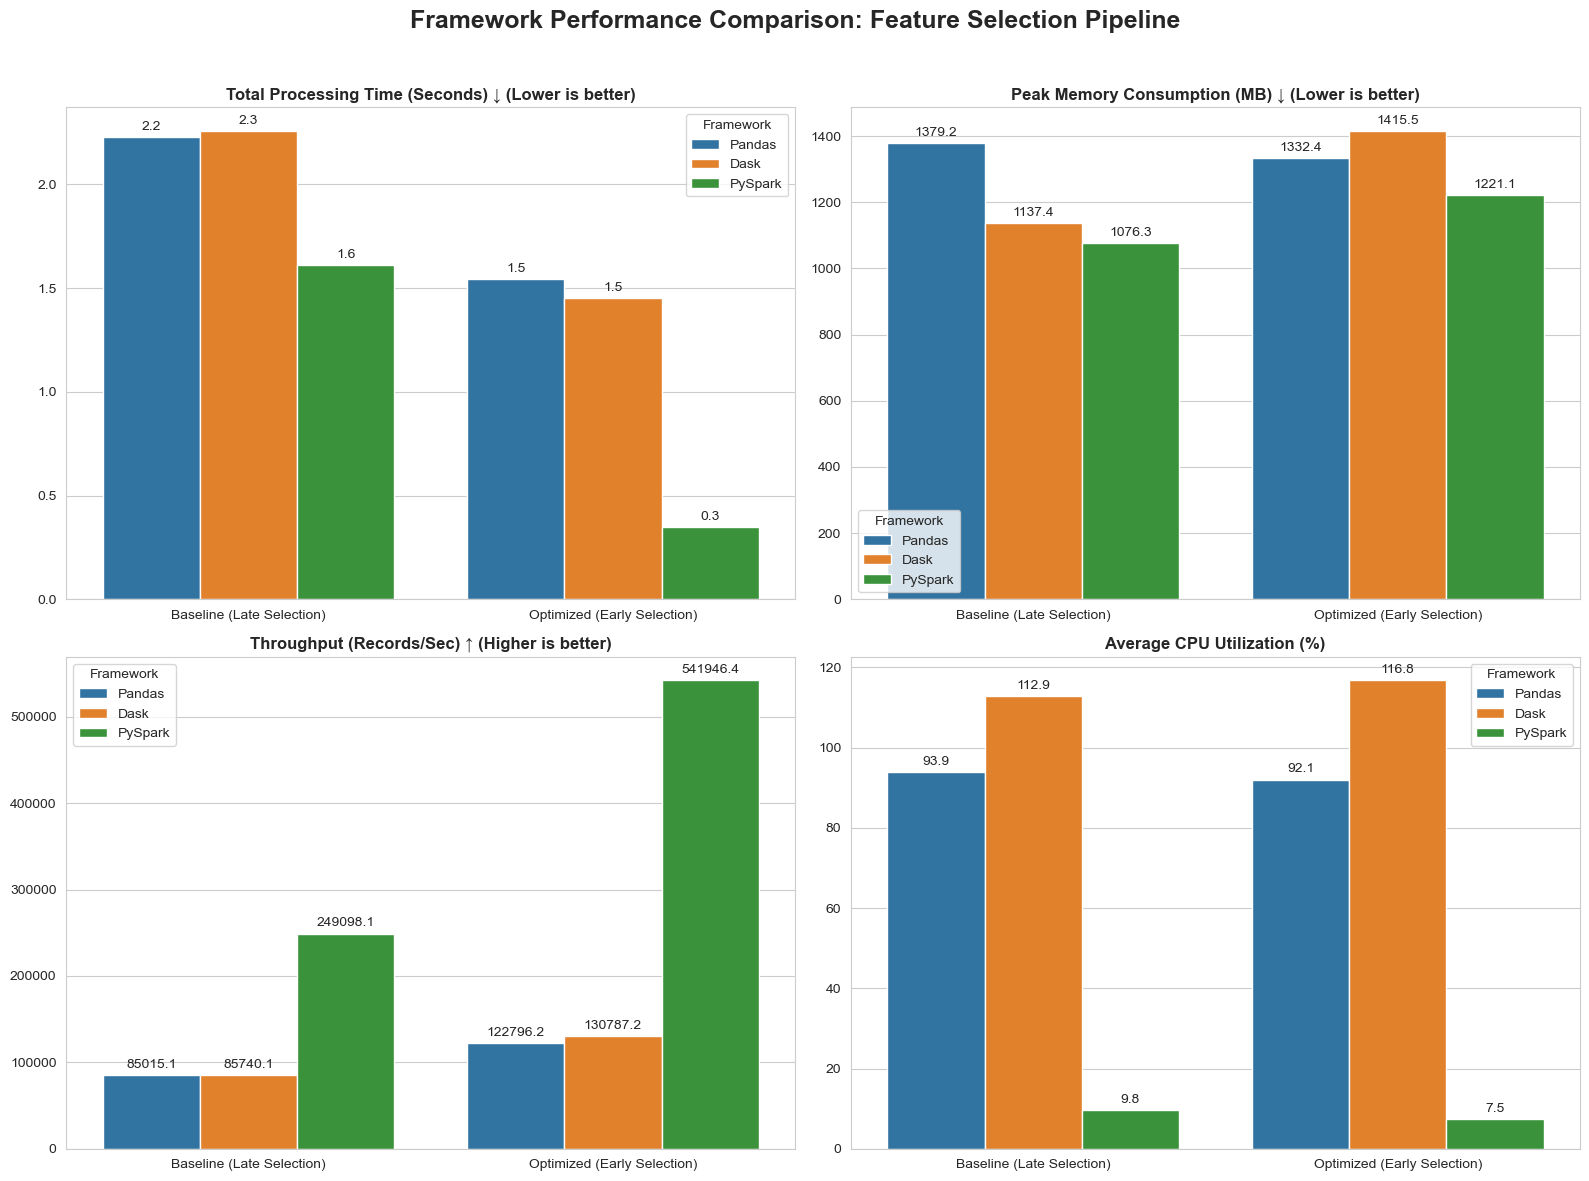

In [6]:
# Load the data we just saved
df_before = pd.read_csv("performance_before.csv")
df_after = pd.read_csv("performance_after.csv")

# Filter only the 'Average' rows for the charts and tables
avg_before = df_before[df_before['Run'] == 'Average'].copy()
avg_after = df_after[df_after['Run'] == 'Average'].copy()

# Print Comparison Tables
print("\n=== AVERAGE PERFORMANCE (BEFORE OPTIMIZATION) ===")
display(avg_before.drop(columns=['Run', 'Version']))

print("\n=== AVERAGE PERFORMANCE (AFTER OPTIMIZATION) ===")
display(avg_after.drop(columns=['Run', 'Version']))

# Combine for easier plotting
avg_before['State'] = 'Baseline (Late Selection)'
avg_after['State'] = 'Optimized (Early Selection)'
plot_df = pd.concat([avg_before, avg_after])

# Set up visual styles and strict framework colors
sns.set_style("whitegrid")
framework_colors = {
    'Pandas': '#1f77b4',  # Distinct Blue
    'Dask': '#ff7f0e',    # Distinct Orange
    'PySpark': '#2ca02c'  # Distinct Green
}

# Create a 2x2 grid of subplots for our 4 metrics
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Framework Performance Comparison: Feature Selection Pipeline', fontsize=18, fontweight='bold')

metrics = [
    ('Total_Time_sec', 'Total Processing Time (Seconds) ↓ (Lower is better)', axes[0, 0]),
    ('Peak_Memory_MB', 'Peak Memory Consumption (MB) ↓ (Lower is better)', axes[0, 1]),
    ('Throughput_rec_per_sec', 'Throughput (Records/Sec) ↑ (Higher is better)', axes[1, 0]),
    ('Avg_CPU_percent', 'Average CPU Utilization (%)', axes[1, 1])
]

# Plot each metric
for col_name, title, ax in metrics:
    sns.barplot(
        data=plot_df, 
        x='State', 
        y=col_name, 
        hue='Framework', 
        palette=framework_colors, 
        ax=ax
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    
    # Add data labels on top of the bars for clarity
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f', padding=3, fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to not cut off main title
plt.show()

# Stop Spark Session gracefully
spark.stop()